In [175]:
#과제
#1. cars.csv와 brand.csv의 데이터 합치기
#2. 카테고리형 변수를 숫자 형태로 변환하기
#3. 결측치 처리하기
#4. Scaler활용해보기

#확인해보기
#1. 국가별 총 브랜드 개수는?
#2. 상관관계가 높은 변수들이 있는지 확인하기 


#평가 문항 및 기준
#1. 데이터의 결함하고, 데이터를 그룹화하여 요약된 정보로 나타낼 수 있는가?
    #데이터의 결합 및 그룹화 기법을 활용하여 요약 정보를 정확하게 나타내었는가?
#2. 데이터의 스케일을 변경하고, 각 스케일러의 특성을 이해하였는가?
    #스케일링을 효과적으로 사용하고 각 스케일러별 특성에 대해 이해하였는가?
#3. 원하는 만큼의 주성분을 추출하고, 기존 데이터에 대한 설명력을 제시할 수 있는가?
    #워하는 주성분 분석에 필요한 데이터 추출이 가능하며, 추출후에는 해당 데이터에 대해 해석이 가능한가?



In [176]:
#중고차 시장에서 궁금한 것 
#중고차 가격에 가장 연관이 있는 요소들은 무엇인가(PCA)
#중고차 중 가격 방어가 가장 잘 되는 것은 무엇인가? (Correlation - 연식과 가격과의 음의 상관관계)

In [177]:
#중고차 데이터 다루기
# Step0. 필요한 모듈 가져오기
import pandas as pd
import seaborn as sns
import numpy as np

df_cars = pd.read_csv('cars.csv')
df_brand = pd.read_csv('brand.csv')

In [178]:
#Step1. 데이터 살펴보기
#cars데이터 살펴보기
df_cars.head()

,title,Price,Mileage(miles),Registration_Year,Previous Owners,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
0,SKODA FABIA,6900,70189,2016,3.0,Diesel,Hatchback,1.4L,Manual,5.0,5.0,Euro 6,NaN
1,VAUXHALL CORSA,1495,88585,2008,4.0,Petrol,Hatchback,1.2L,Manual,3.0,5.0,Euro 4,Full
2,HYUNDAI I30,949,137000,2011,NaN,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 5,NaN
3,MINI HATCH,2395,96731,2010,5.0,Petrol,Hatchback,1.4L,Manual,3.0,4.0,Euro 4,Full
4,VAUXHALL CORSA,1000,85000,2013,NaN,Diesel,Hatchback,1.3L,Manual,5.0,5.0,Euro 5,NaN


In [179]:
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3687 entries, 0 to 3686
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              3687 non-null   object 
 1   Price              3687 non-null   int64  
 2   Mileage(miles)     3687 non-null   int64  
 3   Registration_Year  3687 non-null   int64  
 4   Previous Owners    2276 non-null   float64
 5   Fuel type          3687 non-null   object 
 6   Body type          3687 non-null   object 
 7   Engine             3642 non-null   object 
 8   Gearbox            3687 non-null   object 
 9   Doors              3662 non-null   float64
 10  Seats              3652 non-null   float64
 11  Emission Class     3600 non-null   object 
 12  Service history    540 non-null    object 
dtypes: float64(3), int64(3), object(7)
memory usage: 374.6+ KB


In [180]:
df_cars.describe()

,Price,Mileage(miles),Registration_Year,Previous Owners,Doors,Seats
count,3687.000000,3.687000e+03,3687.000000,2276.000000,3662.000000,3652.000000
mean,5787.301058,8.132854e+04,2011.846216,2.807557,4.321409,4.900329
std,4480.629885,3.941718e+04,5.082387,1.546028,0.986760,0.577046
min,400.000000,1.000000e+00,1953.000000,1.000000,2.000000,2.000000
25%,2490.000000,5.698400e+04,2008.000000,2.000000,3.000000,5.000000
50%,4000.000000,8.000000e+04,2012.000000,3.000000,5.000000,5.000000
75%,7995.000000,1.030000e+05,2015.500000,4.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2025.000000,9.000000,5.000000,7.000000


In [181]:
df_cars.isna().mean()

title                0.000000
Price                0.000000
Mileage(miles)       0.000000
Registration_Year    0.000000
Previous Owners      0.382696
Fuel type            0.000000
Body type            0.000000
Engine               0.012205
Gearbox              0.000000
Doors                0.006781
Seats                0.009493
Emission Class       0.023596
Service history      0.853539
dtype: float64

In [182]:
df_brand.head()

,title,country
0,skoda,Czech Republic
1,vauxhall,United Kingdom
2,hyundai,South Korea
3,mini,United Kingdom
4,ford,United States


In [183]:
df_brand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    48 non-null     object
 1   country  48 non-null     object
dtypes: object(2)
memory usage: 900.0+ bytes


In [184]:
df_brand['title'].nunique() 

48

In [185]:
df_brand['country'].nunique()

12

In [186]:
#Step2. 데이터클리닝

In [ ]:
# 2-1. 결측치 처리
# (1) Previous owner 약 38% 결측치 > 변수에 결측값이 너무 많아 변수 자체를 삭제 (분석에서 사용X)
# (2) Engine 약 1% 결측치 > 모델 / fuel기준
# (3) Emission Class > 출시년도 및 fuel타입과 연관
# (4) Doors 약 0.6% > 모델로 추측 가능한 값 결측치 보완
# (5) Seats 약 0.9% > 모델로 추측 가능한 값 결측치 보완



In [188]:
#(1)Previous Owner 삭제
df_cars = df_cars.drop(columns=['Previous Owners'])

In [189]:
#(2) Engine결측치 확인_총 35개 ->근데 중복값이 매우 많음 35개 중, 28개 -> 완전 중복된 값의 제거 우선
engine_miss = df_cars[df_cars['Engine'].isna()]
duplicates = engine_miss.duplicated().sum()
duplicates

np.int64(28)

In [190]:
df_cars = df_cars.drop_duplicates() #완전 중복된 값들의 제거

In [191]:
engine_miss = df_cars[df_cars['Engine'].isna()]
engine_miss

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
679,BMW 3 SERIES,4200,68060,2007,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,Full
835,TOYOTA MARK X,7500,77000,2021,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,NaN
856,NISSAN CUBIC,4500,47000,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN
1087,AUDI A1,7995,50500,2012,Petrol,Hatchback,NaN,Automatic,3.0,4.0,NaN,NaN
1304,MAZDA MAZDA6,1500,155670,2015,Diesel,Estate,NaN,Manual,NaN,NaN,NaN,NaN
1429,FORD FOCUS,1895,109000,2009,Petrol,Hatchback,NaN,Manual,5.0,5.0,NaN,NaN
1533,CITROEN C1,3900,71000,2015,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN
1619,FORD KA,2490,68837,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,Full
2022,AUDI A3,5750,139225,2012,Diesel,Hatchback,NaN,Automatic,NaN,NaN,NaN,NaN
2136,TOYOTA PRIUS,8950,66000,2012,Petrol Hybrid,Hatchback,NaN,Automatic,NaN,NaN,NaN,NaN


In [192]:
#Fuel Type의 경우 Engine값이 0.0L로 입력
df_cars.loc[df_cars['Fuel type'] == 'Electric', 'Engine'] = '0.0L'#전체 전기차 값들은 0.0L로 변경
engine_miss = df_cars[df_cars['Engine'].isna()]
engine_miss


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
679,BMW 3 SERIES,4200,68060,2007,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,Full
835,TOYOTA MARK X,7500,77000,2021,Petrol,Saloon,NaN,Automatic,NaN,NaN,NaN,NaN
856,NISSAN CUBIC,4500,47000,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN
1087,AUDI A1,7995,50500,2012,Petrol,Hatchback,NaN,Automatic,3.0,4.0,NaN,NaN
1304,MAZDA MAZDA6,1500,155670,2015,Diesel,Estate,NaN,Manual,NaN,NaN,NaN,NaN
1429,FORD FOCUS,1895,109000,2009,Petrol,Hatchback,NaN,Manual,5.0,5.0,NaN,NaN
1533,CITROEN C1,3900,71000,2015,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,NaN
1619,FORD KA,2490,68837,2007,Petrol,Hatchback,NaN,Manual,NaN,NaN,NaN,Full
2022,AUDI A3,5750,139225,2012,Diesel,Hatchback,NaN,Automatic,NaN,NaN,NaN,NaN
2136,TOYOTA PRIUS,8950,66000,2012,Petrol Hybrid,Hatchback,NaN,Automatic,NaN,NaN,NaN,NaN


In [193]:
# 모델 및 fuel타입으로 구하기 -> 동일 모델, 연료종류 없음 
# 보고 싶은 조합 (모델명 + 연료 종류)
target_combos = [
    ('TOYOTA MARK X', 'Petrol'),
    ('NISSAN CUBIC', 'Petrol'),
    ('ISUZU TROOPER', 'Diesel'),
    ('VAUXHALL AMPERA', 'Petrol Plug-in Hybrid'),
]

# 각 조합에 대해 최빈값 출력
for model, fuel in target_combos:
    # 조건에 맞는 행만 필터링
    data = df_cars[(df_cars['title'] == model) & 
                   (df_cars['Fuel type'] == fuel) & 
                   (df_cars['Engine'].notna())]
    
    # 최빈값(mode) 출력
    if not data.empty:
        mode_val = data['Engine']().iloc[0]
        print(f"{model} / {fuel} → Engine 최빈값: {mode_val}")
    else:
        print(f"{model} / {fuel} → 데이터 없음 (mode 구할 수 없음)")

# 모델로만 구하기 -> 해당 모델과 동일 모델 없음
# 보고 싶은 모델 리스트
target_models = ['TOYOTA MARK X', 'NISSAN CUBIC', 'ISUZU TROOPER', 'VAUXHALL AMPERA']

for model in target_models:
    # 해당 모델의 엔진 정보 (결측값 제외)
    data = df_cars[(df_cars['title'] == model) & (df_cars['Engine'].notna())]
    
    # 최빈값 구하기
    if not data.empty:
        mode_val = data['Engine'].mode().iloc[0]
        print(f"{model} → Engine 최빈값: {mode_val}")
    else:
        print(f"{model} → 데이터 없음 (mode 구할 수 없음)")



#추측할 수 있는 base데이터 없으므로 삭제 (실무에서라면 외부에서 데이터를 가지고 오겠지만.. 삭제 하겠습니다.)

TOYOTA MARK X / Petrol → 데이터 없음 (mode 구할 수 없음)
NISSAN CUBIC / Petrol → 데이터 없음 (mode 구할 수 없음)
ISUZU TROOPER / Diesel → 데이터 없음 (mode 구할 수 없음)
VAUXHALL AMPERA / Petrol Plug-in Hybrid → 데이터 없음 (mode 구할 수 없음)
TOYOTA MARK X → 데이터 없음 (mode 구할 수 없음)
NISSAN CUBIC → 데이터 없음 (mode 구할 수 없음)
ISUZU TROOPER → 데이터 없음 (mode 구할 수 없음)
VAUXHALL AMPERA → 데이터 없음 (mode 구할 수 없음)


In [194]:
#engine에서 남은 결측치 삭제
df_cars = df_cars[~df_cars['Engine'].isna()]

In [195]:
#(3)Emission Class 결측치 처리하기  
emission_miss = df_cars[df_cars['Emission Class'].isna()]
emission_miss.info() # 56개 결측치 
emission_miss

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 8 to 3677
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              46 non-null     object 
 1   Price              46 non-null     int64  
 2   Mileage(miles)     46 non-null     int64  
 3   Registration_Year  46 non-null     int64  
 4   Fuel type          46 non-null     object 
 5   Body type          46 non-null     object 
 6   Engine             46 non-null     object 
 7   Gearbox            46 non-null     object 
 8   Doors              31 non-null     float64
 9   Seats              27 non-null     float64
 10  Emission Class     0 non-null      object 
 11  Service history    3 non-null      object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.7+ KB


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
8,VOLVO 740,750,225318,2025,Petrol,Estate,2.3L,Automatic,5.0,NaN,NaN,NaN
95,RENAULT FLUENCE,2490,67104,2010,Diesel,Saloon,1.5L,Manual,4.0,5.0,NaN,NaN
163,HONDA ODYSSEY,2449,88240,2012,Petrol,MPV,2.4L,Automatic,5.0,7.0,NaN,NaN
178,MERCEDES-BENZ CLK,3995,70000,2009,Petrol,Coupe,2.0L,Automatic,2.0,5.0,NaN,NaN
229,MERCEDES-BENZ 260,2995,57400,1991,Petrol,Saloon,2.6L,Automatic,4.0,NaN,NaN,NaN
237,MG MIDGET,1875,75043,1972,Petrol,Convertible,1.3L,Manual,2.0,NaN,NaN,NaN
513,NISSAN LAFESTA,3900,37000,2012,Petrol,MPV,2.0L,Automatic,NaN,NaN,NaN,NaN
595,VAUXHALL ASTRA,3950,56800,2015,Diesel,Hatchback,1.7L,Manual,NaN,5.0,NaN,NaN
645,ROVER MINI,1650,49309,1990,Petrol,Saloon,1.0L,Automatic,2.0,NaN,NaN,NaN
699,MITSUBISHI FTO,8900,58900,2001,Petrol,Coupe,2.0L,Automatic,NaN,NaN,NaN,NaN


In [197]:
#(2) Emission class 결측값을 연도와 fuel type기준 mode값으로 채워넣기
# 1. 연도 그룹핑 함수 정의
def get_year_group(year):
    if pd.isna(year):
        return None
    elif year <= 2000:
        return 'before_2000'
    elif year <= 2005:
        return '2001_2005'
    elif year <= 2010:
        return '2006_2010'
    elif year <= 2014:
        return '2011_2014'
    else:
        return 'after_2015'

# 2. 연도 그룹 열 생성
df_cars['year_group'] = df_cars['Registration_Year'].apply(get_year_group)

# 3. 연도 그룹 + 연료 유형 기준으로 Emission Class의 mode 계산
emission_group_mode = (
    df_cars[df_cars['Emission Class'].notna()]
    .groupby(['year_group', 'Fuel type'])['Emission Class']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'Emission Class': 'Emission_mode'})
)

# 4. 원본 데이터와 mode 테이블 merge
df_cars = df_cars.merge(emission_group_mode, on=['year_group', 'Fuel type'], how='left')

# 5. Emission Class가 결측인 경우에만 mode값으로 채우기
df_cars.loc[df_cars['Emission Class'].isna(), 'Emission Class'] = df_cars.loc[df_cars['Emission Class'].isna(), 'Emission_mode']

# 6. 보조 열 제거
df_cars.drop(columns=['Emission_mode', 'year_group'], inplace=True)

# 7. 결측치 확인
print("✅ 남은 Emission Class 결측치 수:", df_cars['Emission Class'].isna().sum())

✅ 남은 Emission Class 결측치 수: 3


In [199]:
#남은 결측치 확인 후 삭제 여부 결정하기 
emission_miss = df_cars[df_cars['Emission Class'].isna()]
emission_miss

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
1683,MAZDA MX-30,13899,13865,2021,Electric,SUV,0.0L,Automatic,5.0,5.0,NaN,NaN
1761,NISSAN LEAF,5390,60695,2014,Electric,Hatchback,0.0L,Automatic,5.0,5.0,NaN,NaN
2795,VAUXHALL CORSA,13998,28045,2020,Electric,Hatchback,0.0L,Automatic,5.0,5.0,NaN,NaN


In [ ]:
# Emission Class가 있는 electric 차량들만 보기
electric_emission = df_cars[(df_cars['Fuel type'] == 'Electric') & (df_cars['Emission Class'].notna())]

# 비율 확인 -> electic은 emission class가 지정되어있지 않음 / 배출가스가 없기 때문, 적은 숫자이므로 가장 좋은 단계로 편임
electric_emission['Emission Class'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [201]:
df_cars['Fuel type'].value_counts()

Fuel type
Petrol                   1816
Diesel                   1001
Petrol Hybrid              19
Petrol Plug-in Hybrid       5
Electric                    3
Diesel Hybrid               1
Name: count, dtype: int64

In [ ]:
#제일 좋은 단계 확인 -> Euro 6
df_cars['Emission Class'].value_counts()

Emission Class
Euro 5    1110
Euro 4     872
Euro 6     690
Euro 3     134
Euro 2      32
Euro 1       4
Name: count, dtype: int64

In [203]:
df_cars.loc[df_cars['Fuel type'] == 'Electric', 'Emission Class'] = 'Euro 6'

In [ ]:
#(4) Doors 약 0.6% > 모델로 추측 가능한 값 결측치 보완
doors_miss = df_cars[df_cars['Doors'].isna()]
doors_miss.info() # 15개 결측치 
doors_miss

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 403 to 2119
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              15 non-null     object 
 1   Price              15 non-null     int64  
 2   Mileage(miles)     15 non-null     int64  
 3   Registration_Year  15 non-null     int64  
 4   Fuel type          15 non-null     object 
 5   Body type          15 non-null     object 
 6   Engine             15 non-null     object 
 7   Gearbox            15 non-null     object 
 8   Doors              0 non-null      float64
 9   Seats              10 non-null     float64
 10  Emission Class     15 non-null     object 
 11  Service history    1 non-null      object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.5+ KB


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
403,NISSAN LAFESTA,3900,37000,2012,Petrol,MPV,2.0L,Automatic,NaN,NaN,Euro 5,NaN
466,VAUXHALL ASTRA,3950,56800,2015,Diesel,Hatchback,1.7L,Manual,NaN,5.0,Euro 6,NaN
545,MITSUBISHI FTO,8900,58900,2001,Petrol,Coupe,2.0L,Automatic,NaN,NaN,Euro 3,NaN
639,VOLKSWAGEN POLO,6700,49600,2012,Petrol,Hatchback,1.2L,Automatic,NaN,NaN,Euro 5,NaN
741,NISSAN ELGRAND,4200,96000,2017,Petrol,Minibus,2.0L,Automatic,NaN,7.0,Euro 6,NaN
804,HONDA JAZZ,6750,33000,2013,Petrol Hybrid,Hatchback,1.5L,Automatic,NaN,5.0,Euro 5,NaN
818,VOLKSWAGEN POLO,6450,53193,2011,Petrol,Hatchback,1.2L,Automatic,NaN,5.0,Euro 5,NaN
820,BMW 3 SERIES,4000,94000,2007,Petrol,Saloon,2.5L,Automatic,NaN,NaN,Euro 4,NaN
880,VOLKSWAGEN POLO,6900,35515,2012,Petrol,Hatchback,1.2L,Automatic,NaN,5.0,Euro 5,NaN
1245,VOLKSWAGEN GOLF,1895,61000,2001,Petrol,Hatchback,1.6L,Automatic,NaN,5.0,Euro 3,NaN


In [207]:
#Doors 동일 모델명에 동일 seat채워넣기 
# 1. 모델별 최빈값 테이블 만들기
door_mode_table = (
    df_cars[df_cars['Doors'].notna()]
    .groupby('title')['Doors']
    .agg(lambda x: x.mode().iloc[0])  # 최빈값만 추출
    .reset_index()
    .rename(columns={'Doors': 'Doors_mode'})
)

# 2. 원본과 merge
df_cars = df_cars.merge(door_mode_table, on='title', how='left')

# 3. 결측치 채우기
df_cars.loc[df_cars['Doors'].isna(), 'Doors'] = df_cars.loc[df_cars['Doors'].isna(), 'Doors_mode']

# 4. 보조열 제거
df_cars.drop(columns='Doors_mode', inplace=True)

In [ ]:
#Doors 데이터 반영 확인하기 
doors_miss = df_cars[df_cars['Doors'].isna()]
doors_miss.info() # 6개 결측치
doors_miss

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 403 to 2119
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              6 non-null      object 
 1   Price              6 non-null      int64  
 2   Mileage(miles)     6 non-null      int64  
 3   Registration_Year  6 non-null      int64  
 4   Fuel type          6 non-null      object 
 5   Body type          6 non-null      object 
 6   Engine             6 non-null      object 
 7   Gearbox            6 non-null      object 
 8   Doors              0 non-null      float64
 9   Seats              3 non-null      float64
 10  Emission Class     6 non-null      object 
 11  Service history    0 non-null      object 
dtypes: float64(2), int64(3), object(7)
memory usage: 624.0+ bytes


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
403,NISSAN LAFESTA,3900,37000,2012,Petrol,MPV,2.0L,Automatic,NaN,NaN,Euro 5,NaN
545,MITSUBISHI FTO,8900,58900,2001,Petrol,Coupe,2.0L,Automatic,NaN,NaN,Euro 3,NaN
741,NISSAN ELGRAND,4200,96000,2017,Petrol,Minibus,2.0L,Automatic,NaN,7.0,Euro 6,NaN
1836,MARCOS MARTINA,11495,19000,1981,Petrol,Convertible,2.0L,Manual,NaN,2.0,Euro 2,NaN
1936,MITSUBISHI GTO,15000,60742,2003,Petrol,Coupe,3.0L,Manual,NaN,NaN,Euro 3,NaN
2119,HONDA FIT,4450,79208,2010,Petrol,Hatchback,1.3L,Automatic,NaN,5.0,Euro 4,NaN


In [209]:
#Doors 나머지 결측치 삭제 -> 동일 모델이 데이터 내에 없음 (실무에 있었음 그냥 검색했겠지만, 여기서는 삭제)
df_cars = df_cars[~df_cars['Doors'].isna()]


In [ ]:
# (5) Seats 약 0.9% > 모델로 추측 가능한 값 결측치 보완
seats_miss = df_cars[df_cars['Seats'].isna()]
seats_miss.info() # 22개 결측치 
seats_miss

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 8 to 2835
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              22 non-null     object 
 1   Price              22 non-null     int64  
 2   Mileage(miles)     22 non-null     int64  
 3   Registration_Year  22 non-null     int64  
 4   Fuel type          22 non-null     object 
 5   Body type          22 non-null     object 
 6   Engine             22 non-null     object 
 7   Gearbox            22 non-null     object 
 8   Doors              22 non-null     float64
 9   Seats              0 non-null      float64
 10  Emission Class     22 non-null     object 
 11  Service history    0 non-null      object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.2+ KB


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
8,VOLVO 740,750,225318,2025,Petrol,Estate,2.3L,Automatic,5.0,NaN,Euro 6,NaN
90,CITROEN XM,3250,126000,1995,Diesel,Hatchback,2.5L,Manual,5.0,NaN,Euro 2,NaN
185,MERCEDES-BENZ 260,2995,57400,1991,Petrol,Saloon,2.6L,Automatic,4.0,NaN,Euro 2,NaN
190,MG MIDGET,1875,75043,1972,Petrol,Convertible,1.3L,Manual,2.0,NaN,Euro 2,NaN
504,ROVER MINI,1650,49309,1990,Petrol,Saloon,1.0L,Automatic,2.0,NaN,Euro 2,NaN
570,TOYOTA CAMRY,2389,125000,1990,Petrol,Estate,2.0L,Automatic,5.0,NaN,Euro 2,NaN
639,VOLKSWAGEN POLO,6700,49600,2012,Petrol,Hatchback,1.2L,Automatic,5.0,NaN,Euro 5,NaN
721,BMW 3 SERIES,6700,105000,1999,Petrol,Coupe,2.5L,Manual,2.0,NaN,Euro 2,NaN
778,SAAB 900,5995,157000,1992,Petrol,Convertible,2.0L,Manual,2.0,NaN,Euro 1,NaN
816,VOLKSWAGEN GOLF,1250,110000,1996,Petrol,Convertible,2.0L,Manual,2.0,NaN,Euro 1,NaN


In [ ]:
#모델명 기준 seats결측치 채우기
# 1. 모델별 최빈값 테이블 만들기
seats_mode_table = (
    df_cars[df_cars['Seats'].notna()]
    .groupby('title')['Seats']
    .agg(lambda x: x.mode().iloc[0])  # 최빈값
    .reset_index()
    .rename(columns={'Seats': 'Seats_mode'})
)

# 2. merge
df_cars = df_cars.merge(seats_mode_table, on='title', how='left')

# 3. 결측치 채우기
df_cars.loc[df_cars['Seats'].isna(), 'Seats'] = df_cars.loc[df_cars['Seats'].isna(), 'Seats_mode']

# 4. 보조열 제거
df_cars.drop(columns='Seats_mode', inplace=True)

In [ ]:
seats_miss = df_cars[df_cars['Seats'].isna()]
seats_miss.info() # 14개 결측치 
seats_miss

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 8 to 2829
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              14 non-null     object 
 1   Price              14 non-null     int64  
 2   Mileage(miles)     14 non-null     int64  
 3   Registration_Year  14 non-null     int64  
 4   Fuel type          14 non-null     object 
 5   Body type          14 non-null     object 
 6   Engine             14 non-null     object 
 7   Gearbox            14 non-null     object 
 8   Doors              14 non-null     float64
 9   Seats              0 non-null      float64
 10  Emission Class     14 non-null     object 
 11  Service history    0 non-null      object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.4+ KB


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
8,VOLVO 740,750,225318,2025,Petrol,Estate,2.3L,Automatic,5.0,NaN,Euro 6,NaN
90,CITROEN XM,3250,126000,1995,Diesel,Hatchback,2.5L,Manual,5.0,NaN,Euro 2,NaN
185,MERCEDES-BENZ 260,2995,57400,1991,Petrol,Saloon,2.6L,Automatic,4.0,NaN,Euro 2,NaN
190,MG MIDGET,1875,75043,1972,Petrol,Convertible,1.3L,Manual,2.0,NaN,Euro 2,NaN
503,ROVER MINI,1650,49309,1990,Petrol,Saloon,1.0L,Automatic,2.0,NaN,Euro 2,NaN
568,TOYOTA CAMRY,2389,125000,1990,Petrol,Estate,2.0L,Automatic,5.0,NaN,Euro 2,NaN
775,SAAB 900,5995,157000,1992,Petrol,Convertible,2.0L,Manual,2.0,NaN,Euro 1,NaN
950,NISSAN SUNNY,999,60000,1985,Petrol,Saloon,1.3L,Manual,4.0,NaN,Euro 2,NaN
1066,CITROEN BX,4975,96000,1990,Petrol,Hatchback,1.6L,Manual,5.0,NaN,Euro 2,NaN
1553,PROTON PROTON,3995,15760,1995,Petrol,Hatchback,1.5L,Manual,5.0,NaN,Euro 1,NaN


In [ ]:
#seats의 나머지 결측치는 삭제
df_cars = df_cars[~df_cars['Seats'].isna()]

In [227]:
#결측치 확인 
df_cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2825 entries, 0 to 2838
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              2825 non-null   object 
 1   Price              2825 non-null   int64  
 2   Mileage(miles)     2825 non-null   int64  
 3   Registration_Year  2825 non-null   int64  
 4   Fuel type          2825 non-null   object 
 5   Body type          2825 non-null   object 
 6   Engine             2825 non-null   object 
 7   Gearbox            2825 non-null   object 
 8   Doors              2825 non-null   float64
 9   Seats              2825 non-null   float64
 10  Emission Class     2825 non-null   object 
 11  Service history    443 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 286.9+ KB


In [229]:
#다시 데이터프레임 정보확인
df_cars.describe()

,Price,Mileage(miles),Registration_Year,Doors,Seats
count,2825.000000,2.825000e+03,2825.000000,2825.000000,2825.000000
mean,5338.494867,8.399317e+04,2011.401416,4.326726,4.891327
std,4129.409164,3.954235e+04,4.598805,0.981311,0.585966
min,400.000000,1.000000e+00,1987.000000,2.000000,2.000000
25%,2450.000000,5.987900e+04,2008.000000,3.000000,5.000000
50%,3995.000000,8.346700e+04,2011.000000,5.000000,5.000000
75%,6995.000000,1.052020e+05,2014.000000,5.000000,5.000000
max,33900.000000,1.110100e+06,2023.000000,5.000000,7.000000


In [ ]:
#STEP3. 아웃라이어 처리
#(1) price min = 400 , max = 33,900
#(2) Miles = 110만 마일 너무 많은건 확인 필요
#(3) Registeration Year = 너무 오래된것 , 최근 데이터도 한 번 확인 필요

<Axes: xlabel='None', ylabel='Price'>

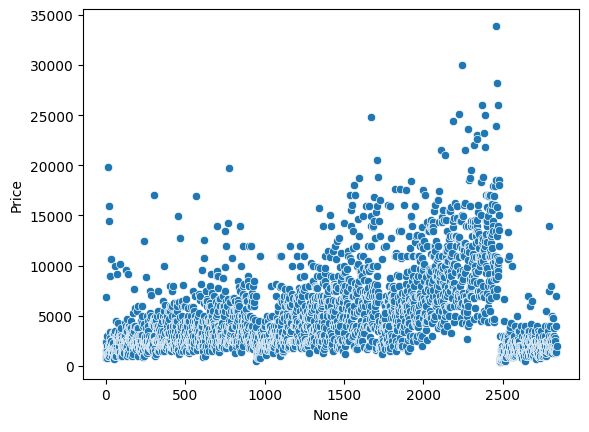

In [ ]:
#(1) price min = 400 , max = 33,900
#scatterplot그리기 
sns.scatterplot(x=df_cars.index, y=df_cars['Price']) 

In [233]:
df_cars.sort_values('Price', ascending=False).head(50) #가격이 비싸긴 하지만, 실제로 수입 비싼차이므로, 가격 max 아웃라이너는 그냥 둔다 

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
2454,MERCEDES-BENZ GLE CLASS,33900,92000,2019,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,NaN
2241,LAND ROVER RANGE ROVER SPORT,30000,46000,2017,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,NaN
2464,BMW X3 SERIES,28240,45155,2019,Diesel,SUV,2.0L,Automatic,5.0,5.0,Euro 6,NaN
2367,SEAT ATECA,25995,222,2023,Petrol,SUV,1.5L,Manual,5.0,5.0,Euro 6,NaN
2468,LAND ROVER RANGE ROVER SPORT,25995,36363,2015,Diesel,SUV,3.0L,Automatic,5.0,5.0,Euro 5,NaN
2223,LAND ROVER RANGE ROVER EVOQUE,25100,26994,2019,Diesel,SUV,2.0L,Manual,5.0,5.0,Euro 6,NaN
2390,AUDI A6,25000,34364,2019,Diesel,Estate,2.0L,Automatic,5.0,5.0,Euro 6,NaN
1672,DS AUTOMOBILES DS 9,24770,16864,2021,Petrol Plug-in Hybrid,Saloon,1.6L,Automatic,4.0,5.0,Euro 6,NaN
2187,LAND ROVER RANGE ROVER EVOQUE,24444,22189,2019,Diesel,SUV,2.0L,Manual,5.0,5.0,Euro 6,NaN
2455,MAZDA MAZDA6 TOURER,23910,23178,2020,Petrol,Estate,2.5L,Automatic,5.0,5.0,Euro 6,NaN


In [ ]:
df_cars.sort_values('Price', ascending=True).head(50) #대체로 소형에, 연식이 오래된 차들이므로 저렴한 가격이 현실에 있을 수 있어 삭제하지 않음

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
2482,SEAT IBIZA,400,120842,2010,Diesel,Hatchback,1.2L,Manual,3.0,5.0,Euro 5,NaN
2514,VAUXHALL ASTRA,450,115000,2005,Diesel,Hatchback,1.7L,Manual,5.0,5.0,Euro 4,NaN
949,VAUXHALL ASTRA,495,97000,2011,Diesel,Hatchback,1.7L,Manual,5.0,5.0,Euro 5,NaN
2483,FORD FIESTA,499,111875,2007,Petrol,Hatchback,1.4L,Manual,3.0,5.0,Euro 4,NaN
2479,RENAULT CLIO,500,138061,2007,Petrol,Hatchback,1.4L,Manual,3.0,5.0,Euro 4,NaN
2636,RENAULT CLIO,500,115083,2007,Petrol,Hatchback,1.2L,Manual,5.0,5.0,Euro 4,NaN
2502,AUDI A6 ALLROAD,595,174009,2003,Diesel,Estate,2.5L,Automatic,5.0,5.0,Euro 4,NaN
2486,FIAT STILO,640,71000,2004,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 4,NaN
2707,SKODA SUPERB,695,160000,2004,Diesel,Saloon,1.9L,Automatic,4.0,5.0,Euro 4,NaN
2500,HONDA CIVIC,699,159630,2004,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 3,NaN


<Axes: xlabel='None', ylabel='Mileage(miles)'>

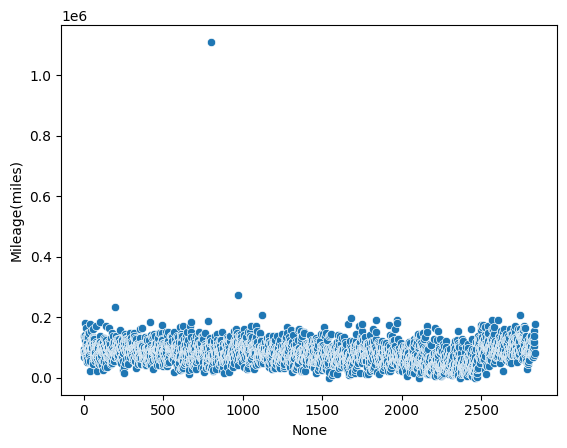

In [ ]:
#(2) Miles = 110만 마일 너무 많은건 확인 필요
sns.scatterplot(x=df_cars.index, y=df_cars['Mileage(miles)']) #일부 아웃라이어로 추정됨

In [ ]:
df_cars.sort_values('Mileage(miles)', ascending=False).head(30) #첫 번째 차량 외에는 합리적임 (연식 오래되었으며, 내구성이 좋은차량들)

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
800,VOLKSWAGEN BEETLE,2495,1110100,2003,Petrol,Hatchback,2.0L,Automatic,3.0,4.0,Euro 4,NaN
969,VOLVO V70,795,274100,2004,Petrol,Estate,2.4L,Automatic,5.0,5.0,Euro 3,NaN
197,AUDI A6 AVANT,2600,234680,2011,Diesel,Estate,2.0L,Manual,5.0,5.0,Euro 5,NaN
2748,BMW 3 SERIES,1995,208000,2009,Diesel,Coupe,3.0L,Automatic,2.0,4.0,Euro 4,NaN
1124,MERCEDES-BENZ S CLASS,4769,207734,2012,Diesel,Saloon,3.0L,Automatic,4.0,5.0,Euro 6,NaN
1684,SKODA OCTAVIA,4995,197790,2013,Diesel,Estate,2.0L,Manual,5.0,5.0,Euro 5,NaN
2571,HONDA ACCORD,950,192567,2007,Diesel,Saloon,2.2L,Manual,4.0,5.0,Euro 4,NaN
1970,VOLKSWAGEN PASSAT,5950,190000,2016,Diesel,Estate,2.0L,Automatic,5.0,5.0,Euro 6,Full
2607,AUDI A3,1250,190000,2009,Diesel,Hatchback,1.9L,Manual,5.0,5.0,Euro 4,NaN
1841,MERCEDES-BENZ S CLASS,1995,189988,2005,Diesel,Saloon,3.2L,Automatic,4.0,5.0,Euro 3,NaN


In [236]:
#마일이 비정상적으로 높은 차 삭제
df_cars = df_cars.drop(800).reset_index(drop=True)

In [ ]:
#(3) Registeration Year = 너무 오래된것 , 25년 데이터도 한 번 확인 필요
df_cars.sort_values('Registration_Year', ascending=True).head(50) #오래되긴 했으나 그 시대에 있떤 차들임 emission class도 옛날 차처럼 낮아서 데이터 사용 

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
1034,BMW 3 SERIES,3495,115000,1987,Petrol,Saloon,1.8L,Automatic,4.0,5.0,Euro 2,NaN
910,PORSCHE 944,6750,121000,1987,Petrol,Coupe,2.5L,Manual,2.0,4.0,Euro 2,NaN
892,VOLKSWAGEN GOLF,2500,124000,1988,Petrol,Hatchback,1.8L,Automatic,5.0,5.0,Euro 2,NaN
2366,VOLKSWAGEN GOLF,7000,130000,1988,Petrol,Convertible,1.8L,Manual,2.0,5.0,Euro 2,NaN
1975,VOLKSWAGEN POLO,2750,31000,1993,Petrol,Coupe,1.0L,Manual,3.0,5.0,Euro 1,NaN
805,VOLKSWAGEN GOLF,1250,110000,1996,Petrol,Convertible,2.0L,Manual,2.0,5.0,Euro 1,NaN
239,LEXUS GS 300,1990,72000,1997,Petrol,Saloon,3.0L,Automatic,4.0,5.0,Euro 2,NaN
808,PEUGEOT 306,2695,25240,1997,Petrol,Hatchback,1.4L,Manual,5.0,5.0,Euro 2,NaN
955,NISSAN PRIMERA,1599,57145,1997,Petrol,Hatchback,1.6L,Manual,5.0,5.0,Euro 2,NaN
849,PEUGEOT 406,3000,67000,1998,Petrol,Coupe,3.0L,Automatic,2.0,4.0,Euro 2,NaN


In [ ]:
df_cars.sort_values('Registration_Year', ascending=False).head(30) #그대로 분석

,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history
2410,VOLKSWAGEN UP,6750,55559,2023,Petrol,Hatchback,1.0L,Manual,5.0,4.0,Euro 6,NaN
2446,MG MG ZS,18515,1,2023,Petrol,SUV,1.5L,Manual,5.0,5.0,Euro 6,NaN
2100,MG MG HS,21495,1048,2023,Petrol,SUV,1.5L,Automatic,5.0,5.0,Euro 6,NaN
2252,RENAULT ARKANA,21495,16228,2023,Petrol,SUV,1.3L,Automatic,5.0,5.0,Euro 6,NaN
2354,SEAT ATECA,25995,222,2023,Petrol,SUV,1.5L,Manual,5.0,5.0,Euro 6,NaN
2352,MG MG ZS,18365,1,2023,Petrol,SUV,1.5L,Manual,5.0,5.0,Euro 6,NaN
2389,RENAULT CLIO,14499,24424,2022,Petrol,Hatchback,1.0L,Manual,5.0,5.0,Euro 6,Full
2425,RENAULT CLIO,13499,28688,2022,Petrol,Hatchback,1.0L,Manual,5.0,5.0,Euro 6,Full
2364,FIAT 500,11495,20000,2022,Petrol,Hatchback,1.0L,Manual,3.0,4.0,Euro 6,NaN
2393,DACIA DUSTER ESTATE,14899,10424,2022,Petrol,SUV,1.0L,Manual,5.0,5.0,Euro 6,NaN


In [ ]:
#STEP4. 범주형 데이터, 문자열 수정 
#(1) cars register year > 연식으로 계산
#(2) Engine 'L'표기 삭제
#(3) Emission class에서 Euro 빼기
#(4) title 에서 제조사 추출
#(5) Service History NaN은 unkown으로 바꾸기
#(6) 범주형 데이터 숫자형으로 변경하기

In [241]:
from datetime import datetime

# (1) Registration_Year → Car_Age
current_year = datetime.now().year
df_cars['Car_Age'] = current_year - df_cars['Registration_Year']

# (2) Engine: "1.4L" → 1.4
df_cars['Engine'] = df_cars['Engine'].str.replace('L', '', regex=False).astype(float)

# (3) Emission Class: "Euro 6" → 6
df_cars['Num_Emission_Class'] = df_cars['Emission Class'].str.extract('(\d+)').astype(float)

# 4. Brand 추출: "SKODA FABIA" → "SKODA"
df_cars['Brand'] = df_cars['title'].str.split().str[0]


df_cars.head()

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
C:\Users\윤선정\AppData\Local\Temp\ipykernel_8428\675613917.py:11: SyntaxWarning: invalid escape sequence '\d'
  df_cars['Num_Emission_Class'] = df_cars['Emission Class'].str.extract('(\d+)').astype(float)


,title,Price,Mileage(miles),Registration_Year,Fuel type,Body type,Engine,Gearbox,Doors,Seats,Emission Class,Service history,Car_Age,Num_Emission_Class,Brand
0,SKODA FABIA,6900,70189,2016,Diesel,Hatchback,1.4,Manual,5.0,5.0,Euro 6,NaN,9,6.0,SKODA
1,VAUXHALL CORSA,1495,88585,2008,Petrol,Hatchback,1.2,Manual,3.0,5.0,Euro 4,Full,17,4.0,VAUXHALL
2,HYUNDAI I30,949,137000,2011,Petrol,Hatchback,1.4,Manual,5.0,5.0,Euro 5,NaN,14,5.0,HYUNDAI
3,MINI HATCH,2395,96731,2010,Petrol,Hatchback,1.4,Manual,3.0,4.0,Euro 4,Full,15,4.0,MINI
4,VAUXHALL CORSA,1000,85000,2013,Diesel,Hatchback,1.3,Manual,5.0,5.0,Euro 5,NaN,12,5.0,VAUXHALL


In [ ]:
#(5) 범주형 데이터 숫자형으로 변경하기 


In [ ]:
#2-1. 문자형 / 숫자 변환 

#(1) cars register year > 연식으로 계산
#(2) Engine 'L'표기 삭제
#(3) Emission class에서 Euro 빼기
#(4) title 에서 제조사 추출

from datetime import datetime

# 1. Registration_Year → Car_Age
current_year = datetime.now().year
df_cars['Car_Age'] = current_year - df_cars['Registration_Year']

# 2. Engine: "1.4L" → 1.4
df_cars['Engine'] = df_cars['Engine'].str.replace('L', '', regex=False).astype(float)

# 3. Emission Class: "Euro 6" → 6
df_cars['Emission_Class'] = df_cars['Emission Class'].str.extract('(\d+)').astype(float)

# 4. Brand 추출: "SKODA FABIA" → "SKODA"
df_cars['Brand'] = df_cars['title'].str.split().str[0]


df_cars.head()